# Debug for SGLD based light YOLO
+ Firstly, we check the loss function is correctly implemented by implementing simple SGD.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# MNISTのダウンロード
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
# 0-1に正規化
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

In [4]:
# 画像サイズ
IMG_SIZE = 128  # 3x3に並べやすいサイズ（拡大する）
NUM_DIGITS = 5  # 1画像中に配置する数字の数

In [5]:
def calc_iou(box1, box2):
    # box: [x_center, y_center, w, h] (normalized)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    # convert to (x_min, y_min, x_max, y_max)
    x1_min = x1 - w1/2
    y1_min = y1 - h1/2
    x1_max = x1 + w1/2
    y1_max = y1 + h1/2
    x2_min = x2 - w2/2
    y2_min = y2 - h2/2
    x2_max = x2 + w2/2
    y2_max = y2 + h2/2

    xi_min = max(x1_min, x2_min)
    yi_min = max(y1_min, y2_min)
    xi_max = min(x1_max, x2_max)
    yi_max = min(y1_max, y2_max)
    inter_w = max(0, xi_max - xi_min)
    inter_h = max(0, yi_max - yi_min)
    inter_area = inter_w * inter_h
    area1 = w1 * h1
    area2 = w2 * h2
    union_area = area1 + area2 - inter_area
    if union_area == 0:
        return 0.0
    return inter_area / union_area

In [6]:
def generate_multimnist_v2(images, labels, n_samples=1000, iou_thresh=0.2):
    out_images = []
    out_boxes = []
    out_classes = []

    for _ in range(n_samples):
        canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        boxes = []
        classes = []

        for _ in range(NUM_DIGITS):
            idx = np.random.randint(0, len(images))
            digit = images[idx]
            label = labels[idx]

            max_attempts = 100
            for attempt in range(max_attempts):
                x_offset = np.random.randint(0, IMG_SIZE - 28)
                y_offset = np.random.randint(0, IMG_SIZE - 28)
                x_center = (x_offset + 14) / IMG_SIZE
                y_center = (y_offset + 14) / IMG_SIZE
                w = 28 / IMG_SIZE
                h = 28 / IMG_SIZE
                new_box = [x_center, y_center, w, h]
                ious = [calc_iou(new_box, b) for b in boxes]
                if all(iou < iou_thresh for iou in ious):
                    break
            else:
                continue

            canvas[y_offset:y_offset+28, x_offset:x_offset+28] = np.maximum(
                canvas[y_offset:y_offset+28, x_offset:x_offset+28],
                digit
            )
            boxes.append(new_box)
            classes.append(label)
            
        out_images.append(canvas)
        out_boxes.append(boxes)
        out_classes.append(classes)

    return np.array(out_images), np.array(out_boxes), np.array(out_classes)

In [7]:
def is_overlap(box1, box2) -> bool:
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    return not (
        x1 + w1 / 2 < x2 - w2 / 2 or
        x1 - w1 / 2 > x2 + w2 / 2 or
        y1 + h1 / 2 < y2 - h2 / 2 or
        y1 - h1 / 2 > y2 + h2 / 2
    )

In [8]:
def generate_multimnist(images, labels, n_samples=1000):
    out_images = []
    out_boxes = []
    out_classes = []

    for _ in range(n_samples):
        canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        boxes = []
        classes = []

        num_digits = np.random.randint(0, NUM_DIGITS + 1)  # 1からNUM_DIGITSまでのランダムな数
        for _ in range(NUM_DIGITS):
            idx = np.random.randint(0, len(images))
            digit = images[idx]
            label = labels[idx]

            x_offset = np.random.randint(0, IMG_SIZE - 28)
            y_offset = np.random.randint(0, IMG_SIZE - 28)
            canvas[y_offset:y_offset+28, x_offset:x_offset+28] = np.maximum(
                canvas[y_offset:y_offset+28, x_offset:x_offset+28],
                digit
            )

            x_center = (x_offset + 14) / IMG_SIZE
            y_center = (y_offset + 14) / IMG_SIZE
            w = 28 / IMG_SIZE
            h = 28 / IMG_SIZE

            boxes.append([x_center, y_center, w, h])
            classes.append(label)
            
        out_images.append(canvas)
        out_boxes.append(boxes)
        out_classes.append(classes)

    return np.array(out_images), np.array(out_boxes), np.array(out_classes)

In [9]:
data_seed = 20251014
np.random.seed(data_seed)

train_images, train_boxes, train_classes = generate_multimnist_v2(x_train, y_train, n_samples=5000)

test_images, test_boxes, test_classes = generate_multimnist_v2(x_test, y_test, n_samples=5000)

In [10]:
trian_images = train_images.astype(np.float32)
train_boxes = train_boxes.astype(np.float32)
train_classes = train_classes.astype(np.float32)

test_images = test_images.astype(np.float32)
test_boxes = test_boxes.astype(np.float32)
test_classes = test_classes.astype(np.float32)

In [11]:
print("Train images:", train_images.shape)
print("Train boxes:", train_boxes.shape)
print("Train classes:", train_classes.shape)


Train images: (5000, 128, 128)
Train boxes: (5000, 5, 4)
Train classes: (5000, 5)


In [12]:
train_boxes[0].dtype

dtype('float32')

In [13]:
focus_ind = 0

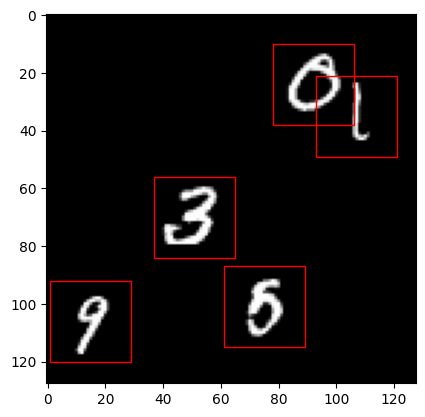

In [14]:
plt.imshow(train_images[focus_ind], cmap='gray')
for box in train_boxes[focus_ind]:
    x, y, w, h = box
    x0 = (x - w/2) * IMG_SIZE
    y0 = (y - h/2) * IMG_SIZE
    rect = plt.Rectangle((x0, y0), w*IMG_SIZE, h*IMG_SIZE, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)
plt.show()

# SGLD based light YOLO

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Model and loss

In [16]:
def conv_block(x, filters, kernel=3, stride=1):
    x = layers.Conv2D(filters, kernel, stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    return x

In [17]:
def tiny_yolo_like(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_objects=NUM_DIGITS, num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = conv_block(inputs, 16)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 32)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 256)
    x = layers.Flatten()(x)

    box_out = layers.Dense(num_objects * 4, activation="sigmoid", name="bboxes")(x)
    class_out = layers.Dense(num_objects * num_classes, activation="softmax", name="classes")(x)

    model = models.Model(inputs=inputs, outputs=[box_out, class_out])
    return model

In [18]:
def tiny_yolo_like_v2(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_objects=NUM_DIGITS, num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = conv_block(inputs, 16)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 32)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 256)
    x = layers.Flatten()(x)

    box_out = layers.Dense(num_objects * 4, activation="sigmoid", name="bboxes")(x)
    class_out = layers.Dense(num_objects * num_classes, name="classes_dense")(x)
    class_out = layers.Reshape((num_objects, num_classes))(class_out)
    class_out = layers.Softmax(axis=-1, name="classes")(class_out)
    
    model = models.Model(inputs=inputs, outputs=[box_out, class_out])
    return model

In [19]:
# model = tiny_yolo_like()
model = tiny_yolo_like_v2()

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ leaky_re_lu_2[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ leaky_re_lu_3[0]

 Total params: 1,541,254 (5.88 MB)

 Trainable params: 1,540,262 (5.88 MB)

 Non-trainable params: 992 (3.88 KB)

In [21]:
w_list = model.trainable_variables
lr = 1e-5

In [22]:
def compute_loss(images, boxes, classes):
    pred_boxes, pred_classes = model(images, training=True)

    boxes = tf.reshape(boxes, (boxes.shape[0], -1))
    box_loss = tf.reduce_mean(tf.square(pred_boxes - boxes))

    classes = tf.reshape(classes, (classes.shape[0], -1))
    class_loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(classes, pred_classes))
    return box_loss + class_loss

In [23]:
def compute_loss_v2(images, boxes, classes):
    pred_boxes, pred_classes = model(images, training=True)

    boxes = tf.reshape(boxes, (boxes.shape[0], -1))
    box_loss = tf.reduce_mean(tf.square(pred_boxes - boxes))

    classes_onehot = tf.one_hot(tf.cast(classes, tf.int32), depth=10)
    class_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(classes_onehot, pred_classes)
    )
    return box_loss + class_loss

In [24]:
def compute_loss_v3(images, boxes, classes, prior_weight = 0.01):
    pred_boxes, pred_classes = model(images, training=True)

    boxes = tf.reshape(boxes, (boxes.shape[0], -1))
    box_loss = tf.reduce_mean(tf.square(pred_boxes - boxes))

    classes_onehot = tf.one_hot(tf.cast(classes, tf.int32), depth=10)
    class_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(classes_onehot, pred_classes)
    )

    # 事前分布項を追加
    prior = tf.add_n([tf.reduce_sum(tf.square(w)) for w in model.trainable_variables])
    
    return box_loss + class_loss + prior_weight * prior

In [25]:
# def yolo_loss(y_true, y_pred):
#     coord_loss = tf.reduce_mean(tf.square(y_true[..., :4] - y_pred[..., :4]))
#     obj_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
#         y_true[..., 4:], y_pred[..., 4:]
#     ))
#     return coord_loss + obj_loss

In [26]:
loss_func = compute_loss_v3

# Adamベースで勾配法

In [27]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_history = []

In [28]:
batch_size = 32
num_steps = 500
disp_interval = 50

In [29]:
for step in range(num_steps):
    idx = np.random.randint(0, len(train_images), batch_size)
    batch_imgs = train_images[idx][..., np.newaxis]
    batch_boxes = train_boxes[idx]
    batch_classes = train_classes[idx]
    with tf.GradientTape() as tape:
        loss = loss_func(batch_imgs, batch_boxes, batch_classes)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    loss_history.append(loss.numpy())
    if step % disp_interval == 0:
        print(f"Step {step}, loss: {loss.numpy()}")

Step 0, loss: 12.424301147460938
Step 50, loss: 10.398768424987793
Step 100, loss: 8.849691390991211
Step 150, loss: 7.736474990844727
Step 200, loss: 6.697839736938477
Step 250, loss: 5.912288665771484
Step 300, loss: 5.492704391479492
Step 350, loss: 5.109696388244629
Step 400, loss: 4.84274959564209
Step 450, loss: 4.537256240844727


In [32]:
model.save("tiny_yolo_like_v2.h5")

# より小さいモデルで検証
+ 3層NNを今回のロジックに適用して上手く動作するか確認する

## データ生成

In [170]:
M = 1
H0 = 1
N = 1
train_n = 100
test_n = 100

In [171]:
data_seed = 20251022
np.random.seed(data_seed)

In [172]:
true_w1 = np.random.normal(size=(M, H0))
true_w2 = np.random.normal(size=(H0, N))

In [173]:
train_X = np.random.normal(scale=2, size=(train_n, M))
true_func = np.tanh(train_X @ true_w1) @ true_w2
train_Y = true_func + np.random.normal(size=(train_n, N))

In [174]:
test_X = np.random.normal(scale=2, size=(test_n, M))
true_func = np.tanh(test_X @ true_w1) @ true_w2
test_Y = true_func + np.random.normal(size=(test_n, N))

## モデルと損失関数の定義

In [175]:
H = 1

In [176]:
def simple_nn(input_shape=M, output_shape=N, H=5):
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Dense(H, activation='tanh', use_bias=False)(inputs)
    output = layers.Dense(output_shape, use_bias=False)(x)
    model = models.Model(inputs=inputs, outputs=[output])    
    return model

In [196]:
simple_nn_model = simple_nn(H=H)

In [197]:
simple_nn_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             1 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             1 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [198]:
def compute_simple_loss(input_val, output_val, prior_weight=0.1):
    pred_val = simple_nn_model(input_val, training=True)
    output_loss = tf.reduce_mean(tf.keras.losses.mse(output_val, pred_val))
    
    prior = tf.add_n([tf.reduce_sum(tf.square(w)) for w in model.trainable_variables])
    return output_loss + prior_weight*prior

# SGLD

In [199]:
loss_func = compute_simple_loss

In [200]:
w_list = simple_nn_model.trainable_variables

In [201]:
batch_size = 32
num_steps = 5000
sample_interval = 50
samples = []

In [202]:
ln_seed = 20241022
np.random.seed(ln_seed)

In [207]:
eps_t = 1e-3
decay_cycle = 50
decay_factor = 0.95

In [208]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_history = []
grads_history = []

In [209]:
@tf.function
def sgld_step(input_val, output_val, eps_t):
    with tf.GradientTape() as tape:
        loss = loss_func(input_val, output_val)
    grads = tape.gradient(loss, w_list)
    for var, grad in zip(w_list, grads):

        noise = tf.random.normal(shape=var.shape, stddev=tf.sqrt(2 * eps_t))
        var.assign_sub(0.5 * eps_t * grad)
        var.assign_add(noise)
    return loss, grads

In [210]:
for step in range(num_steps):
    if step % decay_cycle == 0:
        eps_t *= decay_factor
    
    idx = np.random.randint(0, len(train_X), batch_size)
    batch_X = train_X[idx]
    batch_Y = train_Y[idx]

    loss, grads = sgld_step(batch_X, batch_Y, eps_t)
    grads_history.append([g.numpy() for g in grads])
    # optimizer.apply_gradients(zip(grads, simple_nn_model.trainable_variables))
    if step % sample_interval == 0:
        print(f"Step {step}, loss: {loss.numpy()}")
        samples.append([v.numpy() for v in w_list])

Step 0, loss: 22.94161605834961
Step 50, loss: 22.71280860900879
Step 100, loss: 22.741559982299805
Step 150, loss: 22.972496032714844
Step 200, loss: 22.667566299438477
Step 250, loss: 22.66065216064453
Step 300, loss: 22.828813552856445
Step 350, loss: 22.990116119384766
Step 400, loss: 23.00080680847168
Step 450, loss: 22.672439575195312
Step 500, loss: 22.670608520507812
Step 550, loss: 22.561342239379883
Step 600, loss: 23.033905029296875
Step 650, loss: 23.13906478881836
Step 700, loss: 23.888830184936523
Step 750, loss: 22.711881637573242
Step 800, loss: 22.847442626953125
Step 850, loss: 23.965360641479492
Step 900, loss: 23.383283615112305
Step 950, loss: 23.315824508666992
Step 1000, loss: 23.299232482910156
Step 1050, loss: 22.882680892944336
Step 1100, loss: 23.056161880493164
Step 1150, loss: 22.967449188232422
Step 1200, loss: 23.624614715576172
Step 1250, loss: 23.48219871520996
Step 1300, loss: 24.064212799072266
Step 1350, loss: 23.961641311645508
Step 1400, loss: 23.8

KeyboardInterrupt: 

In [194]:
np.linalg.norm(np.array([(grad[0].squeeze(), grad[1].squeeze()) for grad in grads_history]), axis=1)

(5000,)

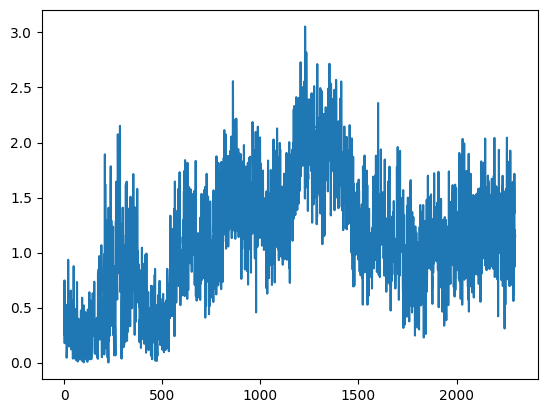

In [211]:
plt.plot(
    np.arange(len(grads_history)),
    np.linalg.norm(np.array([(grad[0].squeeze(), grad[1].squeeze()) for grad in grads_history]), axis=1),
)

In [159]:
post_params = np.array([(sample[0].squeeze(), sample[1].squeeze()) for sample in samples])

In [166]:
post_params[-50:]

array([[-0.3644952 ,  0.6675843 ],
       [-0.36890715,  0.72613883],
       [-0.32583547,  0.6896462 ],
       [-0.32691982,  0.71562326],
       [-0.35890755,  0.7502432 ],
       [-0.4099925 ,  0.73565227],
       [-0.390925  ,  0.7220288 ],
       [-0.37621906,  0.7393454 ],
       [-0.40122885,  0.7326676 ],
       [-0.37340516,  0.72665983],
       [-0.33457515,  0.704165  ],
       [-0.41408625,  0.7321331 ],
       [-0.46130818,  0.7445288 ],
       [-0.43822312,  0.8086061 ],
       [-0.4592968 ,  0.7945576 ],
       [-0.4601748 ,  0.80291826],
       [-0.5174811 ,  0.76782227],
       [-0.5097207 ,  0.76837504],
       [-0.52949214,  0.7232434 ],
       [-0.56712013,  0.7033194 ],
       [-0.5649197 ,  0.7245908 ],
       [-0.53746796,  0.7177276 ],
       [-0.5533437 ,  0.72748125],
       [-0.59047115,  0.75902045],
       [-0.5549764 ,  0.7696024 ],
       [-0.50136167,  0.7090912 ],
       [-0.4617372 ,  0.7326973 ],
       [-0.4623498 ,  0.7575194 ],
       [-0.5181646 ,

In [165]:
true_w1, true_w2

(array([[-1.51352927]]), array([[-0.01382059]]))

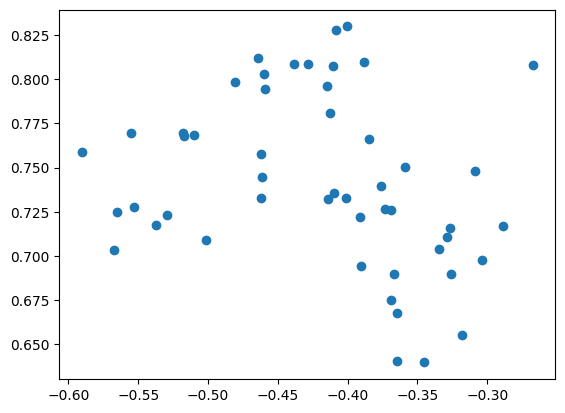

In [167]:
plt.scatter(post_params[-50:,0], post_params[-50:,1])